In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/content/Restaurant.csv", encoding="latin1")


In [3]:
df.head()

,web_scraper_order,web_scraper_start_url,name,cuisine,price,dining_rating,link,dining_votes,delivery_rating,delivery_votes,location
0,1774775120-1,https://www.zomato.com/kochi,KO KO RO Cafe,"Desserts, Juices, Indo-Chinese, French, Chines...",?700 for two,New,https://www.zomato.com/kochi/ko-ko-ro-cafe-ern...,0,-,0,"40/12, Thrikkakara Circle, Thammanam, Pullepad..."
1,1774775124-2,https://www.zomato.com/kochi,KFC,"Burger, Fast Food, Rolls",?450 for two,-,https://www.zomato.com/kochi/kfc-ernakulam-cit...,1,-,1,"Ground Floor, Door 355/B & First Floor, Door 3..."
2,1774775132-3,https://www.zomato.com/kochi,Tabasco,"Arabian, Shawarma, Burger, Salad","?1,000 for two",-,https://www.zomato.com/kochi/tabasco-ernakulam...,1,-,1,"Door 30/461/K, Que West Properties, Ernakulam ..."
3,1774775135-4,https://www.zomato.com/kochi,Hotel Salwa,"South Indian, Kerala",?400 for two,3.4,https://www.zomato.com/kochi/hotel-salwa-ernak...,26,3.4,26,"XI/1394, OPP Bus Stop, Thoppumpady Jn, Ernakul..."
4,1774775138-5,https://www.zomato.com/kochi,Badai Bungalow,"Sandwich, Shawarma, Street Food, Tea",?250 for two,-,https://www.zomato.com/kochi/badai-bungalow-er...,0,-,0,"Vadakkedath House, Aluva Circle, Ernakulam Cit..."


In [4]:
df.shape

(3820, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3820 entries, 0 to 3819
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   web_scraper_order      3820 non-null   object
 1   web_scraper_start_url  3820 non-null   object
 2   name                   3820 non-null   object
 3   cuisine                3820 non-null   object
 4   price                  3820 non-null   object
 5   dining_rating          3820 non-null   object
 6   link                   3820 non-null   object
 7   dining_votes           3820 non-null   object
 8   delivery_rating        3820 non-null   object
 9   delivery_votes         3820 non-null   object
 10  location               3820 non-null   object
dtypes: object(11)
memory usage: 328.4+ KB


In [6]:
df['dining_rating'].value_counts()

,count
dining_rating,
-,629
4.3,368
4.2,306
4.5,301
4.4,290
4.1,290
4,283
3.9,229
3.8,152


In [7]:
df['dining_rating'] = df['dining_rating'].replace(['-', 'New'], None)

In [8]:
df['dining_rating'] = pd.to_numeric(df['dining_rating'], errors='coerce')

In [9]:
df['price'].value_counts()

,count
price,
?100 for one,357
?200 for one,300
?150 for one,285
?300 for two,276
"?1,000 for two",194
...,...
"?4,100 for two",1
"?5,800 for two",1
"?10,000 for two",1


In [10]:
# convert to string
df['price'] = df['price'].astype(str)

# identify 'for two'
df['is_two'] = df['price'].str.contains('for two', na=False)

# remove text
df['price'] = df['price'].str.replace('for one', '', regex=False)
df['price'] = df['price'].str.replace('for two', '', regex=False)

# remove symbols
df['price'] = df['price'].str.replace('₹', '', regex=False)
df['price'] = df['price'].str.replace('?', '', regex=False)
df['price'] = df['price'].str.replace(',', '', regex=False)

# strip spaces
df['price'] = df['price'].str.strip()

# convert to numeric
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# divide only 'for two' rows
df.loc[df['is_two'], 'price'] = df.loc[df['is_two'], 'price'] / 2

# drop helper column
df.drop('is_two', axis=1, inplace=True)

In [11]:
df['price'].value_counts()

,count
price,
150.0,561
200.0,469
100.0,453
250.0,218
500.0,198
...,...
2050.0,1
2900.0,1
5000.0,1


In [12]:
df['location'].value_counts()

,count
location,
"1270 C, Ground Floor, Kolloth Arcade, Eranhipalam, Rarichan Road, Bilathikkulam, Kozhikode",9
"16/112, Near Victoria College, Vidyut Nagar, Palakkad",8
"ITC Grand Chola, 63, Mount Road, Guindy, Chennai",4
"Mannuthi Junction, Mannuthy, Thrissur",4
"61/11600, 1st Floor, Calicut Mall, Near Stadium Junction, Puthiyara Road, Palayam, Kozhikode",3
...,...
"Aiswarya Ramanathapuram, Manali Road, Vidyut Nagar, Palakkad",1
"23/596-5, 6, Kalliyat Building, Stadium ByePass Road, Near Noorjehan, Sulthan, Kalmandapam, Palakkad",1
"21/636, Head Post Office, Kalmandapam, Palakkad",1


In [13]:
df['location'] = df['location'].str.split(',').str[-1]
df['location'] = df['location'].str.strip()

In [14]:
df['location'].value_counts()

,count
location,
Thrissur,501
Mumbai,500
Trivandrum,499
Chennai,488
Bangalore,482
Kozhikode,305
Kottayam,202
Kochi,200
Palakkad,162


In [15]:
df['location'] = df['location'].str.lower().str.strip()

In [16]:
df['location'] = df['location'].str.replace('.', '', regex=False)

In [17]:
df = df[~df['location'].isin(['', '#name?'])]     #invalid

In [18]:
df['location'] = df['location'].str.title()

In [19]:
df['location'].value_counts().head(15)

,count
location,
Thrissur,501
Mumbai,500
Trivandrum,499
Chennai,488
Bangalore,482
Kozhikode,305
Kottayam,202
Kochi,200
Palakkad,162


In [20]:
df['delivery_rating'].value_counts()

,count
delivery_rating,
-,1504
4.5,289
4.3,274
4.4,262
4.2,214
4.1,187
3.9,165
4.6,135
4,115


In [21]:
# replace invalid values
df['delivery_rating'] = df['delivery_rating'].replace(['-', 'New'], None)

# convert to numeric
df['delivery_rating'] = pd.to_numeric(df['delivery_rating'], errors='coerce')

In [22]:
df['delivery_votes'].value_counts()

,count
delivery_votes,
0,1116
1,190
2,132
4,88
3,75
...,...
"4,146",1
"1,006",1
"4,209",1


In [23]:
# convert to string
df['delivery_votes'] = df['delivery_votes'].astype(str)

# remove commas
df['delivery_votes'] = df['delivery_votes'].str.replace(',', '', regex=False)

# convert to numeric
df['delivery_votes'] = pd.to_numeric(df['delivery_votes'], errors='coerce')

In [24]:
df['dining_votes'] = df['dining_votes'].astype(str).str.replace(',', '', regex=False)
df['dining_votes'] = pd.to_numeric(df['dining_votes'], errors='coerce')


In [25]:
df.isnull().sum()

,0
web_scraper_order,0
web_scraper_start_url,0
name,0
cuisine,0
price,8
dining_rating,712
link,0
dining_votes,52
delivery_rating,1529
delivery_votes,52


In [26]:
df['dining_votes'] = df['dining_votes'].fillna(0)
df['delivery_rating'] = df['delivery_rating'].fillna(0)
df['delivery_votes'] = df['delivery_votes'].fillna(0)


df = df.dropna(subset=['dining_rating', 'price'])


print(df.isnull().sum())

web_scraper_order        0
web_scraper_start_url    0
name                     0
cuisine                  0
price                    0
dining_rating            0
link                     0
dining_votes             0
delivery_rating          0
delivery_votes           0
location                 0
dtype: int64


In [27]:
location_rating = df.groupby('location')['dining_rating'].median()

In [28]:
import pickle

location_rating_dict = location_rating.to_dict()

pickle.dump(location_rating_dict, open("location_rating.pkl", "wb"))

In [27]:
df['success'] = df['dining_rating'].apply(lambda x: 1 if x >= 4 else 0)

In [28]:
df['success'].value_counts()

,count
success,
1,2080
0,1019


In [29]:
df['has_delivery'] = df['delivery_rating'].apply(lambda x: 1 if x > 0 else 0)

In [30]:
df['has_delivery'].value_counts()

,count
has_delivery,
1,2265
0,834


In [31]:
df['price_category'] = pd.cut(df['price'],
                               bins=[0, 300, 600, 1000, 2000],
                               labels=['Low', 'Medium', 'High', 'Luxury'])

df['price_category'].value_counts()

,count
price_category,
Low,1578
High,567
Medium,536
Luxury,379


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df.dtypes

,0
web_scraper_order,object
web_scraper_start_url,object
name,object
cuisine,object
price,float64
dining_rating,float64
link,object
dining_votes,float64
delivery_rating,float64
delivery_votes,float64


<Axes: xlabel='dining_rating', ylabel='Count'>

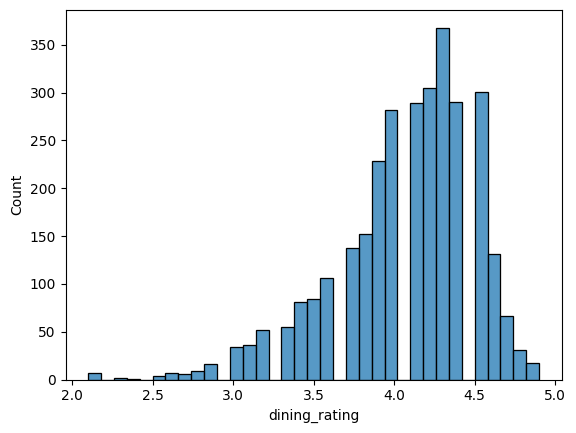

In [ ]:
sns.histplot(df['dining_rating'])

<Axes: xlabel='price', ylabel='Count'>

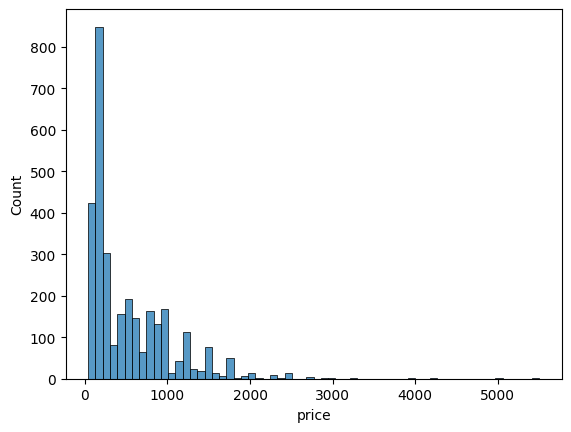

In [ ]:
sns.histplot(df['price'])

<Axes: xlabel='dining_votes', ylabel='Count'>

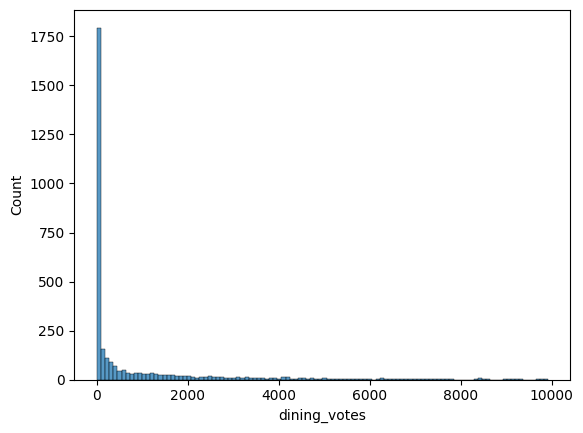

In [ ]:
sns.histplot(df['dining_votes'])

<Axes: xlabel='delivery_rating', ylabel='Count'>

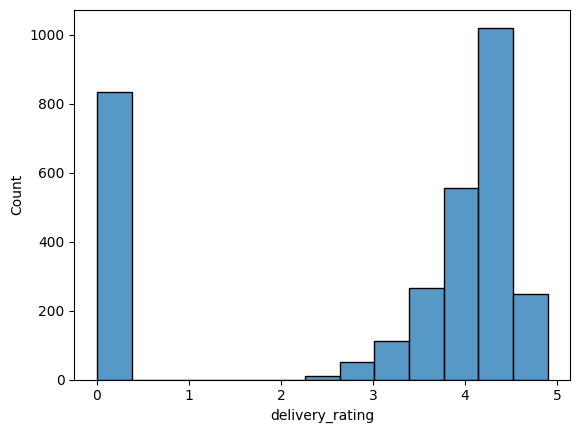

In [ ]:
sns.histplot(df['delivery_rating'])

<Axes: xlabel='delivery_votes', ylabel='Count'>

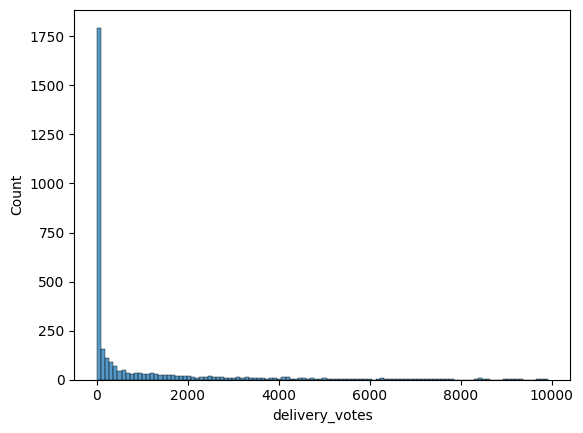

In [ ]:
sns.histplot(df['delivery_votes'])

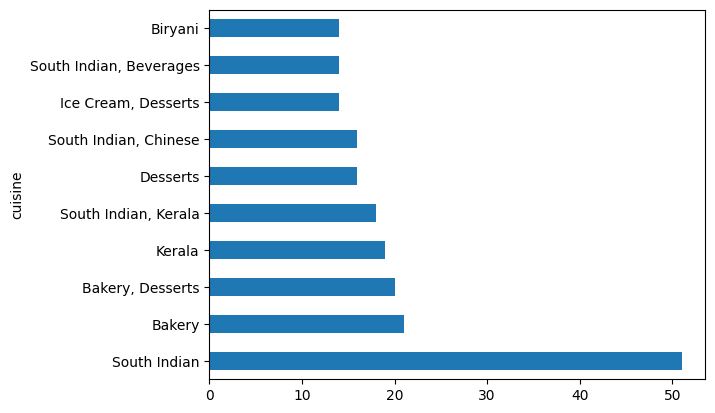

In [ ]:
top_cuisines = df['cuisine'].value_counts().head(10)
top_cuisines.plot(kind='barh')
plt.show()

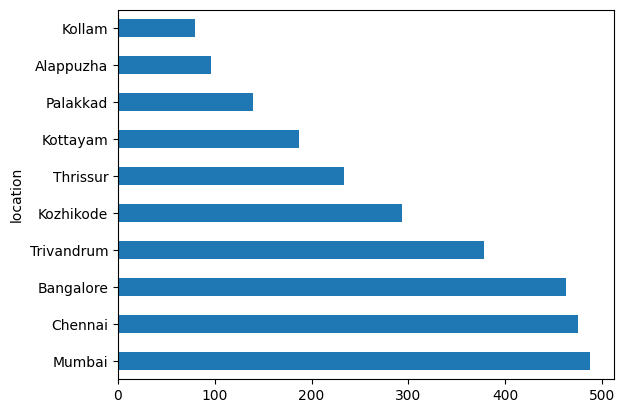

In [ ]:
top_location = df['location'].value_counts().head(10)
top_location.plot(kind='barh')
plt.show()

<Axes: xlabel='count', ylabel='price_category'>

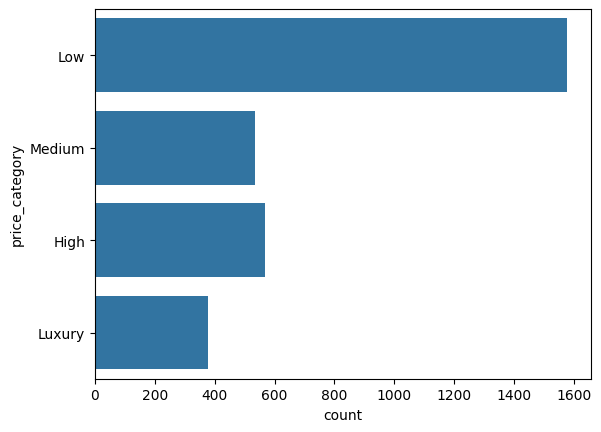

In [ ]:
sns.countplot(df['price_category'])

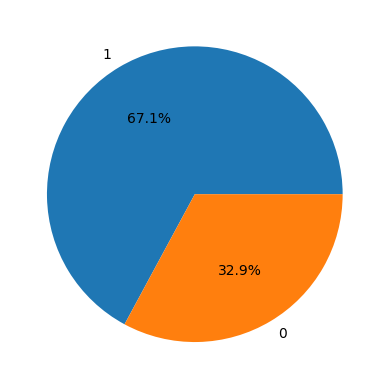

In [ ]:
x = df['success'].value_counts()
plt.pie(x.values,
        labels=x.index,
        autopct='%1.1f%%')
plt.show()

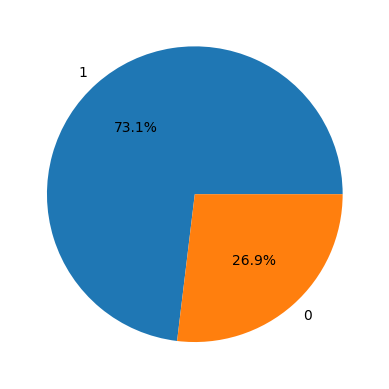

In [ ]:
x = df['has_delivery'].value_counts()
plt.pie(x.values,
        labels=x.index,
        autopct='%1.1f%%')
plt.show()

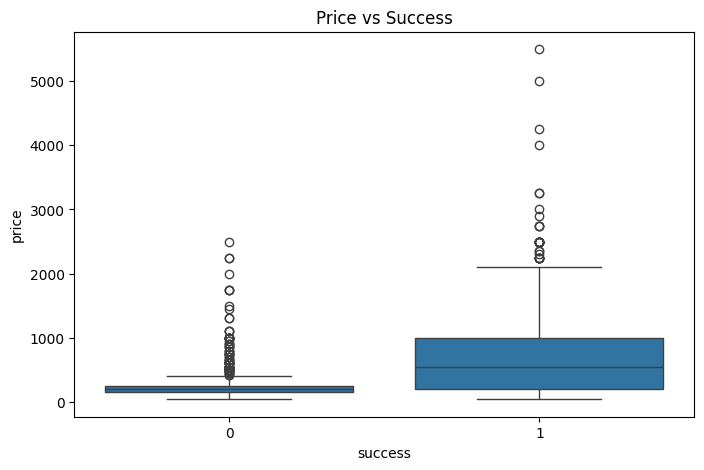

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='success', y='price', data=df)
plt.title('Price vs Success')
plt.show()

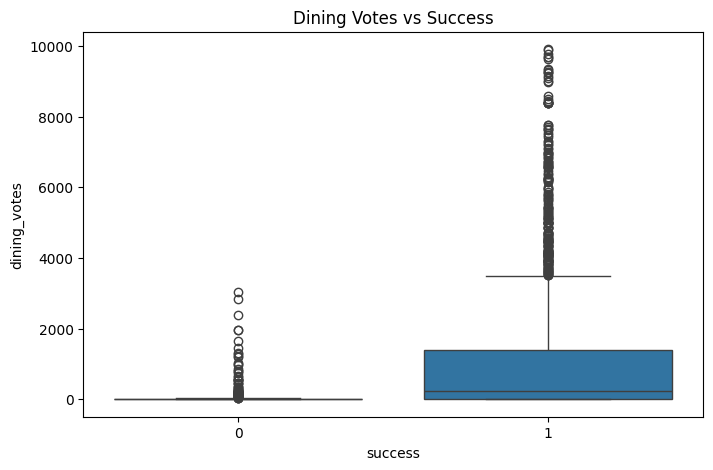

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='success', y='dining_votes', data=df)
plt.title('Dining Votes vs Success')
plt.show()

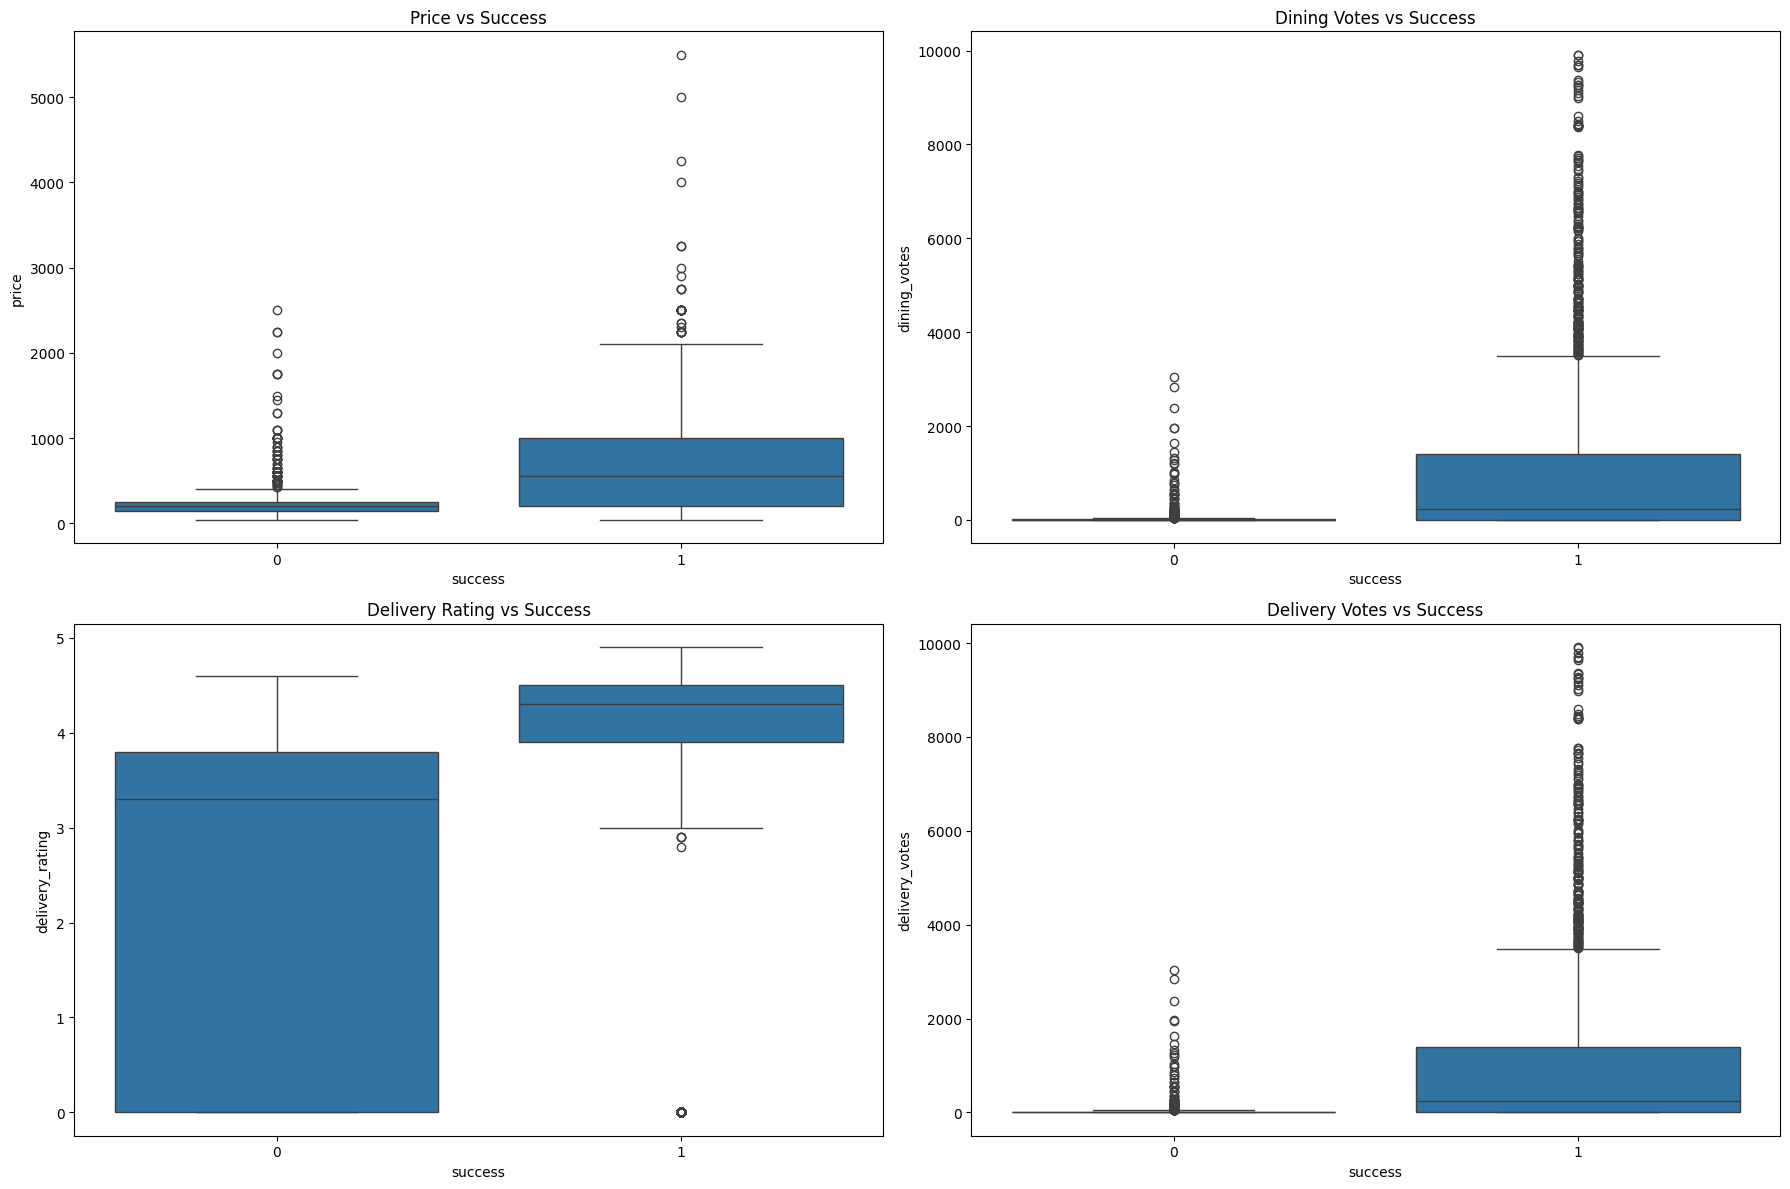

In [ ]:
plt.figure(figsize=(18, 12))

# Price vs Success
plt.subplot(2, 2, 1)
sns.boxplot(x='success', y='price', data=df)
plt.title('Price vs Success')

# Dining Votes vs Success
plt.subplot(2, 2, 2)
sns.boxplot(x='success', y='dining_votes', data=df)
plt.title('Dining Votes vs Success')

# Delivery Rating vs Success
plt.subplot(2, 2, 3)
sns.boxplot(x='success', y='delivery_rating', data=df)
plt.title('Delivery Rating vs Success')

# Delivery Votes vs Success
plt.subplot(2, 2, 4)
sns.boxplot(x='success', y='delivery_votes', data=df)
plt.title('Delivery Votes vs Success')

plt.tight_layout()
plt.show()

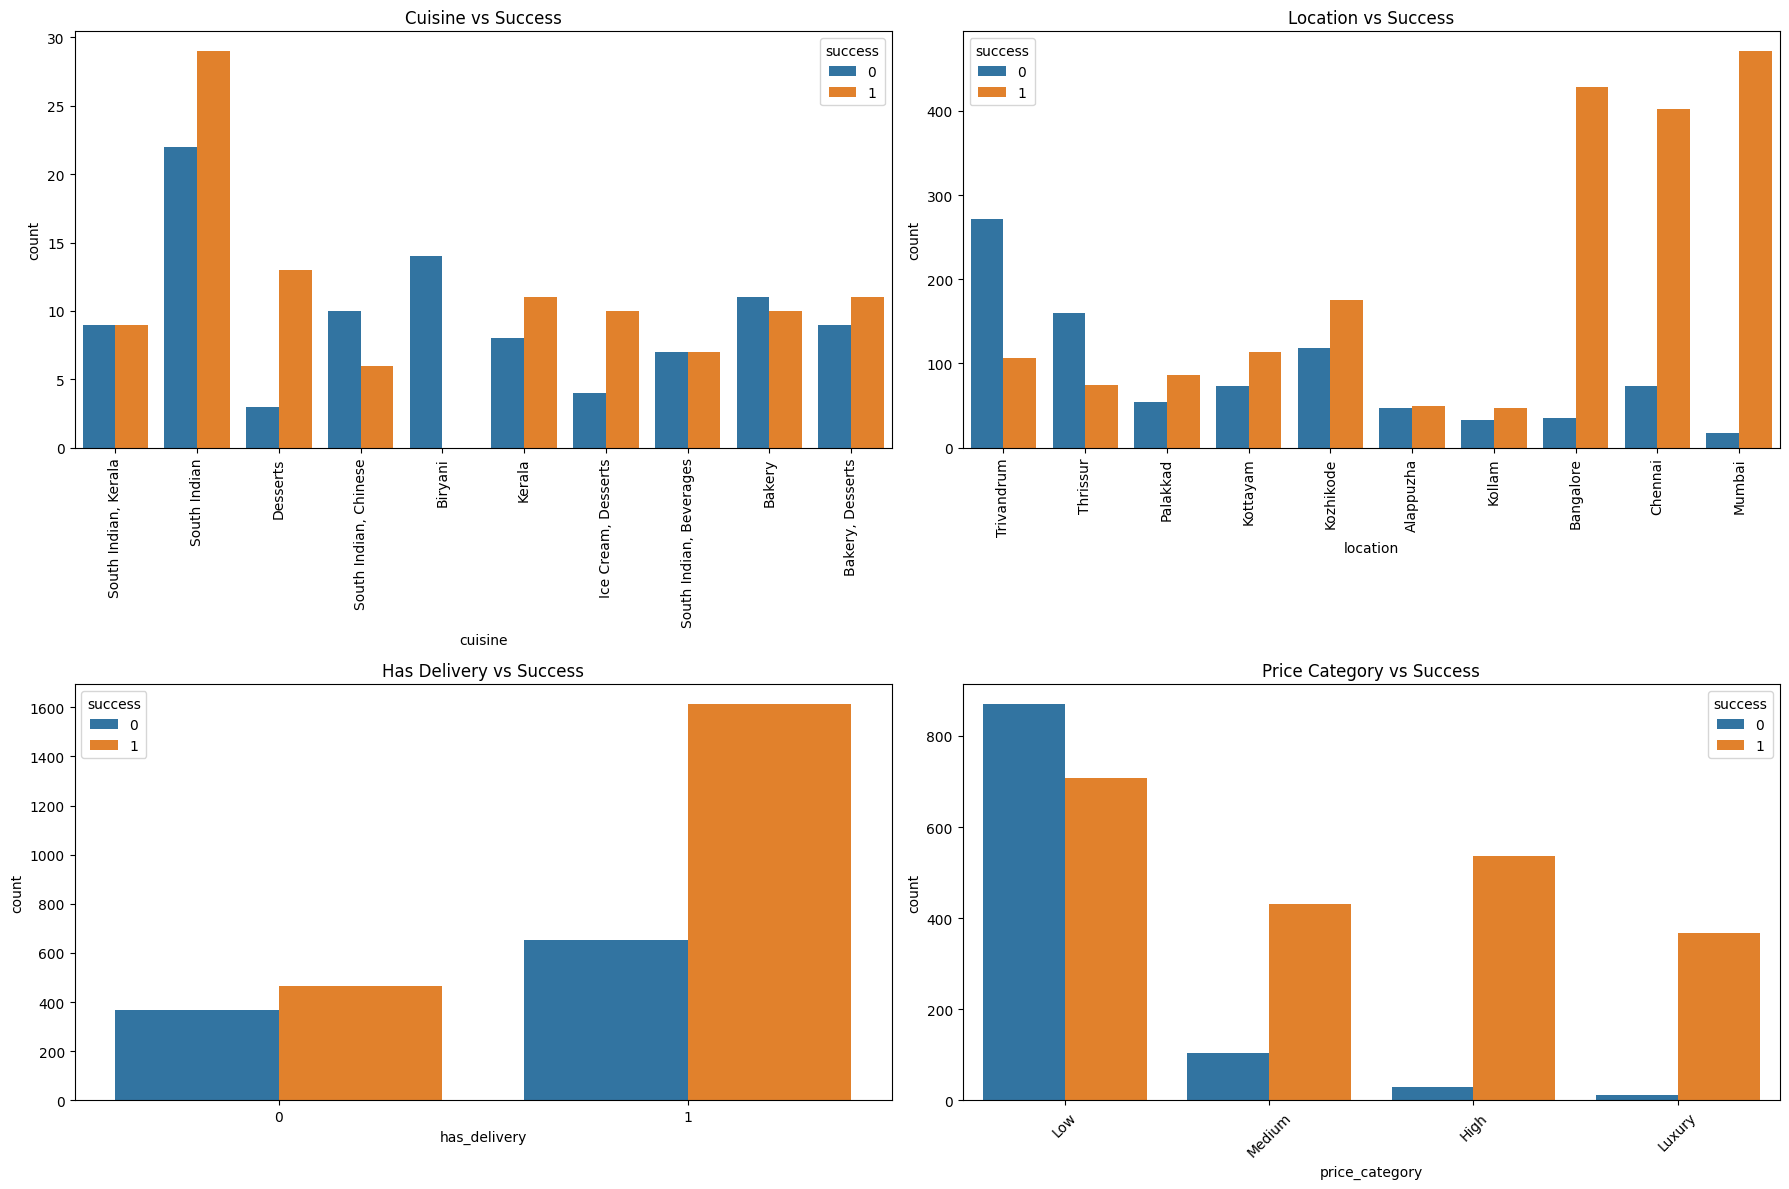

In [ ]:
plt.figure(figsize=(18, 12))

# Cuisine vs Success
plt.subplot(2, 2, 1)
top_cuisines = df['cuisine'].value_counts().head(10).index
sns.countplot(x='cuisine', hue='success', data=df[df['cuisine'].isin(top_cuisines)])
plt.xticks(rotation=90)
plt.title('Cuisine vs Success')

# Location vs Success
plt.subplot(2, 2, 2)
top_locations = df['location'].value_counts().head(10).index
sns.countplot(x='location', hue='success', data=df[df['location'].isin(top_locations)])
plt.xticks(rotation=90)
plt.title('Location vs Success')

# Has Delivery vs Success
plt.subplot(2, 2, 3)
sns.countplot(x='has_delivery', hue='success', data=df)
plt.title('Has Delivery vs Success')

# Price Category vs Success
plt.subplot(2, 2, 4)
sns.countplot(x='price_category', hue='success', data=df)
plt.xticks(rotation=45)
plt.title('Price Category vs Success')

plt.tight_layout()
plt.show()

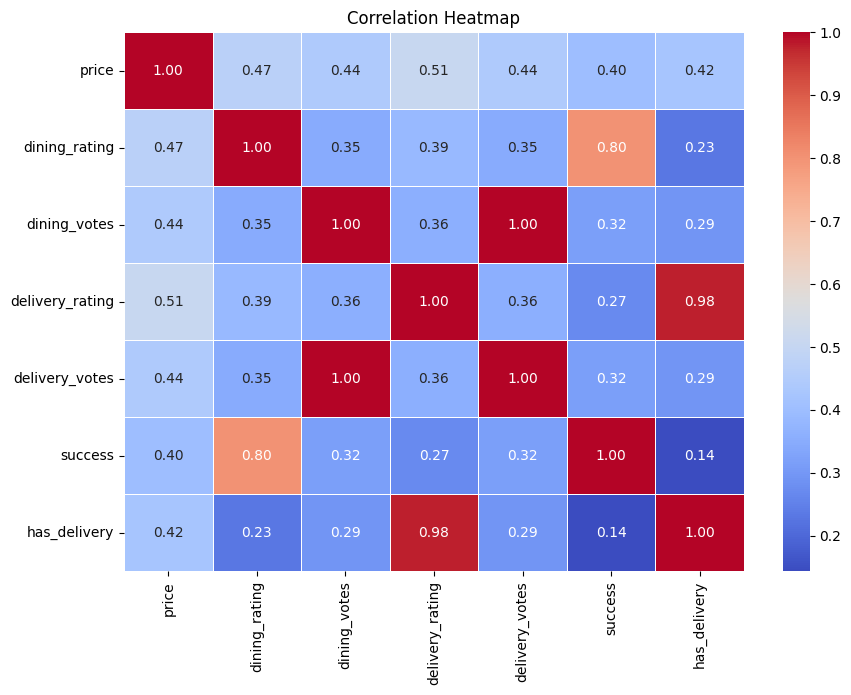

In [ ]:
plt.figure(figsize=(10,7))
numeric_cols = ['price', 'dining_rating', 'dining_votes', 'delivery_rating', 'delivery_votes', 'success', 'has_delivery']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [34]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

# 1. Cuisines clean cheyyunnu
df['cuisine_split'] = df['cuisine'].apply(
    lambda x: [i.strip() for i in x] if isinstance(x, list) else str(x).split(', ')
)

# 2. All cuisines edukkunnu
top_cuisines = df['cuisine_split'].explode().str.strip().value_counts().index.tolist()
print('Total Cuisines:', len(top_cuisines))

# 3. Filter
df['cuisine_filtered'] = df['cuisine_split'].apply(
    lambda x: [i.strip() for i in x if i.strip() in top_cuisines]
)

# 4. Encode
mlb = MultiLabelBinarizer(classes=top_cuisines)
encoded = mlb.fit_transform(df['cuisine_filtered'])

# 5. DataFrame
encoded_df = pd.DataFrame(encoded, columns=top_cuisines, index=df.index)

# Drop redundant columns
df = df.drop(columns=['cuisine', 'cuisine_split', 'cuisine_filtered'], errors='ignore')
df = pd.concat([df, encoded_df], axis=1)

print("Final Shape:", df.shape)

Total Cuisines: 117
Final Shape: (3099, 130)


In [35]:
pickle.dump(mlb, open("mlb.pkl", "wb"))

In [36]:
location_rating = df.groupby('location')['dining_rating'].median()

def assign_tier(rating):
    if rating >= 4.3:
        return 1
    elif rating >= 4.0:
        return 2
    else:
        return 3

df['location_tier'] = df['location'].map(location_rating).apply(assign_tier)

In [37]:
df['location_tier'].value_counts()

,count
location_tier,
1,1426
2,971
3,702


In [38]:
df.columns

Index(['web_scraper_order', 'web_scraper_start_url', 'name', 'price',
       'dining_rating', 'link', 'dining_votes', 'delivery_rating',
       'delivery_votes', 'location',
       ...
       'Russian', '', 'Snacks', 'South American', 'British', 'Kashmiri',
       'Peruvian', 'Poké', 'Himachali', 'location_tier'],
      dtype='object', length=131)

In [ ]:
df.dtypes

,0
web_scraper_order,object
web_scraper_start_url,object
name,object
price,float64
dining_rating,float64
...,...
Kashmiri,int64
Peruvian,int64
Poké,int64
Himachali,int64


In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['price_category'] = le.fit_transform(df['price_category'])
print(df['price_category'].value_counts())

price_category
1    1578
0     567
3     536
2     379
4      39
Name: count, dtype: int64


In [40]:
df.dtypes

,0
web_scraper_order,object
web_scraper_start_url,object
name,object
price,float64
dining_rating,float64
...,...
Kashmiri,int64
Peruvian,int64
Poké,int64
Himachali,int64


In [41]:
df.columns

Index(['web_scraper_order', 'web_scraper_start_url', 'name', 'price',
       'dining_rating', 'link', 'dining_votes', 'delivery_rating',
       'delivery_votes', 'location',
       ...
       'Russian', '', 'Snacks', 'South American', 'British', 'Kashmiri',
       'Peruvian', 'Poké', 'Himachali', 'location_tier'],
      dtype='object', length=131)

In [42]:
import numpy as np

df['dining_votes'] = np.log1p(df['dining_votes'])

In [43]:
drop_cols = ['web_scraper_order', 'web_scraper_start_url', 'name',
             'link', 'location', 'dining_rating','delivery_votes',
             'delivery_rating','price','location_rating']

df = df.drop(columns=drop_cols)
print(df.columns.tolist())

['dining_votes', 'success', 'has_delivery', 'price_category', 'Beverages', 'North Indian', 'Chinese', 'Desserts', 'South Indian', 'Biryani', 'Fast Food', 'Continental', 'Asian', 'Italian', 'Pizza', 'Kerala', 'Shake', 'Seafood', 'Burger', 'Arabian', 'Juices', 'Sandwich', 'Bakery', 'Pasta', 'Salad', 'Street Food', 'Cafe', 'Ice Cream', 'Coffee', 'Mughlai', 'Japanese', 'Bar Food', 'Sushi', 'Kebab', 'American', 'Sichuan', 'Shawarma', 'Rolls', 'Thai', 'European', 'Healthy Food', 'Momos', 'Mexican', 'Oriental', 'Tea', 'Mandi', 'Modern Indian', 'Finger Food', 'Wraps', 'BBQ', 'Mediterranean', 'Lebanese', 'Korean', 'Andhra', 'Middle Eastern', 'Alcoholic Beverages', 'Cake', 'Waffle', 'Indo-Chinese', 'Mithai', 'Chettinad', 'Tamil', 'Pancake', 'Steak', 'Maharashtrian', 'Cantonese', 'Goan', 'Turkish', 'Bubble Tea', 'Vietnamese', 'French', 'Malaysian', 'Tibetan', 'Charcoal Chicken', 'Roast Chicken', 'Rajasthani', 'Mangalorean', 'Grilled Chicken', 'Gujarati', 'Singaporean', 'Panini', 'Malwani', 'Burme

In [44]:
print('' in df.columns)

True


In [45]:
df.drop(columns=[''], inplace=True)
print(df.shape)

(3099, 121)


In [46]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['success'])
y = df['success']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Class distribution:", y_train.value_counts().to_dict())

X_train: (2479, 120)
X_test: (620, 120)
Class distribution: {1: 1664, 0: 815}


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


lr = LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.717741935483871

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.87      0.67       204
           1       0.91      0.64      0.75       416

    accuracy                           0.72       620
   macro avg       0.73      0.76      0.71       620
weighted avg       0.79      0.72      0.73       620



In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

svc = SVC(kernel='rbf', random_state=42, class_weight='balanced')
svc.fit(X_train, y_train)

y_pred_svc = svc.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svc))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svc))

Accuracy: 0.7209677419354839

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.90      0.68       204
           1       0.93      0.63      0.75       416

    accuracy                           0.72       620
   macro avg       0.74      0.77      0.72       620
weighted avg       0.80      0.72      0.73       620



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7274193548387097

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.64      0.61       204
           1       0.81      0.77      0.79       416

    accuracy                           0.73       620
   macro avg       0.70      0.71      0.70       620
weighted avg       0.74      0.73      0.73       620



In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb_bal = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=2080/1019
)
xgb_bal.fit(X_train, y_train)

y_pred_xgb_bal = xgb_bal.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb_bal))
print(classification_report(y_test, y_pred_xgb_bal))

Accuracy: 0.7967741935483871
              precision    recall  f1-score   support

           0       0.77      0.54      0.64       204
           1       0.80      0.92      0.86       416

    accuracy                           0.80       620
   macro avg       0.79      0.73      0.75       620
weighted avg       0.79      0.80      0.79       620



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7838709677419354
              precision    recall  f1-score   support

           0       0.68      0.66      0.67       204
           1       0.84      0.84      0.84       416

    accuracy                           0.78       620
   macro avg       0.76      0.75      0.75       620
weighted avg       0.78      0.78      0.78       620



In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

param_grid = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [3, 5, 7],
    'learning_rate':   [0.01, 0.1, 0.2],
    'scale_pos_weight':[2080/1019]
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'scale_pos_weight': 2.041216879293425}
Accuracy: 0.7983870967741935
              precision    recall  f1-score   support

           0       0.78      0.54      0.64       204
           1       0.81      0.92      0.86       416

    accuracy                           0.80       620
   macro avg       0.79      0.73      0.75       620
weighted avg       0.80      0.80      0.79       620



In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

all_models = {
    'Logistic Regression': lr,
    'SVC':                 svc,
    'Decision Tree':       dt,
    'Random Forest':       rf,
    'XGBoost':             xgb_bal,
    'XGBoost (Tuned)':     best_xgb,
}

results = []

for name, model in all_models.items():
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        'Model':        name,
        'Accuracy':     round(accuracy_score(y_test, y_pred), 4),
        'F1 (class 0)': round(report['0']['f1-score'], 4),
        'F1 (class 1)': round(report['1']['f1-score'], 4),
    })

df_results = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print(df_results.to_string(index=False))

              Model  Accuracy  F1 (class 0)  F1 (class 1)
    XGBoost (Tuned)    0.7984        0.6398        0.8600
            XGBoost    0.7968        0.6379        0.8587
      Random Forest    0.7839        0.6683        0.8397
      Decision Tree    0.7274        0.6079        0.7911
                SVC    0.7210        0.6802        0.7525
Logistic Regression    0.7177        0.6692        0.7539


       feature  importance
 location_tier    0.097668
  dining_votes    0.049127
          Cafe    0.027117
  has_delivery    0.020921
         Momos    0.020888
price_category    0.020512
         Kebab    0.019660
         Wraps    0.019540
       Sichuan    0.018847
   Finger Food    0.018690
      Desserts    0.018064
         Tamil    0.017826
      Sandwich    0.017825
         Shake    0.017660
      American    0.017576


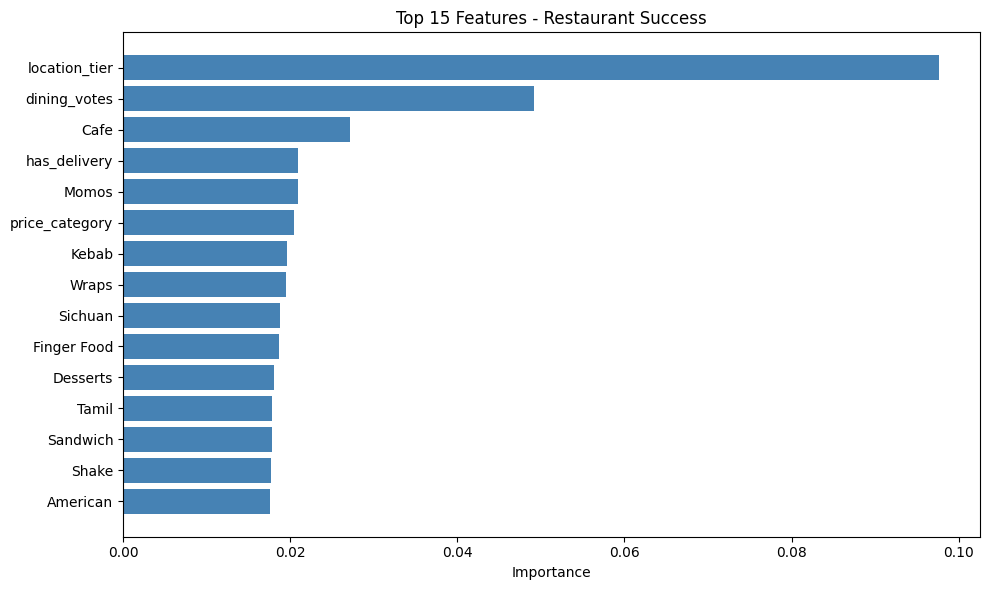

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = best_xgb.feature_importances_
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

print(feat_imp.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(feat_imp['feature'][::-1], feat_imp['importance'][::-1], color='steelblue')
plt.xlabel('Importance')
plt.title('Top 15 Features - Restaurant Success')
plt.tight_layout()
plt.show()

Report — Restaurant Success Prediction

## 1. Objective
Build a classification model to predict whether a restaurant will be successful (1) or not (0).

---

## 2. Dataset
- Total samples : 3099
- Features      : 121
- Target        : success (1 = success, 0 = failure)
- Class split   : 1664 success, 815 failure (imbalanced)

---

## 3. Models Trained

| Model               | Accuracy | F1 (class 0) | F1 (class 1) |
|---------------------|----------|--------------|--------------|
| XGBoost (Tuned)     | 0.7984   | 0.6398       | 0.8600       |
| XGBoost             | 0.7968   | 0.6379       | 0.8587       |
| Random Forest       | 0.7839   | 0.6683       | 0.8397       |
| Decision Tree       | 0.7274   | 0.6079       | 0.7911       |
| Logistic Regression | 0.7210   | 0.6802       | 0.7525       |
| SVC                 | 0.7177   | 0.6692       | 0.7539       |

---

## 4. Best Model — XGBoost (Tuned)

**Parameters:**
- n_estimators     : 100
- max_depth        : 7
- learning_rate    : 0.2
- scale_pos_weight : 2.04 (to handle class imbalance)

**Performance:**
- Accuracy        : 79.84%
- F1 Score (Success class) : 0.86
- Recall (Class 1): 92% — detected 383 out of 416 success cases

---

## 5. Feature Importance (Top 5)

| Rank | Feature       | Importance |
|------|---------------|------------|
| 1    | location_tier | 0.0977     |
| 2    | dining_votes  | 0.0491     |
| 3    | Cafe          | 0.0271     |
| 4    | has_delivery  | 0.0209     |
| 5    | Momos         | 0.0209     |

---

## 6. Key Findings

- **Location** is the most influential factor in determining restaurant success
- **Dining votes** (customer ratings) is the second most important feature
- Restaurants with **delivery service** have a higher chance of success
- Cuisine type is less important compared to location and customer votes

---

## 7. Conclusion

The XGBoost (Tuned) model achieves 80% accuracy in predicting restaurant success.
Location tier and customer votes are the most critical factors that determine
whether a restaurant will succeed or fail.


In [ ]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)

print("Model saved!")

Model saved!
